In [65]:

from dotenv import load_dotenv
load_dotenv()



from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

import uuid
from typing import List
from pydantic import BaseModel, Field
from langchain_google_genai import GoogleGenerativeAIEmbeddings,ChatGoogleGenerativeAI

In [66]:
llm1 = ChatGoogleGenerativeAI(
model="gemini-2.5-flash",
# temperature=0.2,
# max_tokens=100,   
# timeout=None,
# max_retries=2,
# other params...
)

In [67]:

# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

# user is duplicating the memories now we will update 
# the memories are only stored once we will send the memories to llm also


In [68]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [69]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [70]:
class MemoryDecision1(BaseModel):
    should_write:bool = Field(description="Whether to store any memories")

    memories: List[str] = Field(default_factory=list,description="Atomic user memories to store")

In [71]:
memory_extractor = llm1.with_structured_output(MemoryDecision)

In [72]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [85]:
def remember_node(state:MessagesState,config:RunnableConfig,*,store:BaseStore):
    user_id = config["configurable"]["user_id"]

    ns = ("user",user_id,"details")

    # existing memory
    items = store.search(ns)
    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    last_msg = state["messages"][-1].content
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing)),
            {"role":"user","content":last_msg}
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(ns,str(uuid.uuid4()),{"data":mem.text})

In [80]:
# ---------------------------
# 2) System prompt
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [81]:

# ----------------------------
# 3) Graph: START -> remember -> END
#    (Creates memories, but does NOT use them to answer)
# ----------------------------

def remember_only_node(state:MessagesState,config:RunnableConfig,store:BaseStore):
    user_id = config["configurable"]["user_id"]

    namespace = ("user",user_id,"details")

    # take latest user message 
    last_msg = state["messages"][-1].content
    # LLM decides what to store
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )

            ),
            {"role":"user","content":last_msg}
        ]
    )
    # Write to store (LTM)
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace,str(uuid.uuid4()),{"data":mem})
    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.
    return {"messages": [{"role": "assistant", "content": "Assistant Noted."}]}


In [82]:
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = llm1.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

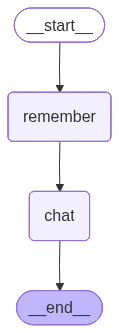

In [86]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START,"remember")
builder.add_edge("remember","chat")
builder.add_edge("chat",END)

graph = builder.compile(store=store)

graph

In [87]:
# ----------------------------
# 4) Run it (provide user_id in config)
# ----------------------------

config = {"configurable":{"user_id":"u1"}}

result = graph.invoke(
    {"messages":[{"role":"user","content":"My age is 24"}]},
    config
)

In [92]:
result["messages"][-1].content

"Thanks for letting me know! I've noted that your age is 24. This helps me understand a little more about you.\n\nTo help me assist you even better in the future, here are a few questions you might consider answering:\n\n1.  What are your main interests or hobbies?\n2.  What kind of projects are you currently working on, if any?\n3.  Is there anything specific you'd like my help with today or in the near future?"

In [96]:
items = store.search(("user", "u1", "details"))

for item in items:
    print(item.value['data'])

My age is 24.
I teach Maths.


In [94]:
result = graph.invoke({"messages":[{"role":"user","content":"I teach Maths"}]},config)

In [97]:
result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result['messages'][-1].content)

Hey there! You asked for a simple explanation of Generative AI, and I can definitely help with that.

Think of Generative AI, or GenAI, as a super-smart computer program that doesn't just *understand* information, but can *create* brand new things from scratch.

Imagine you're teaching your Maths students all the rules and patterns of algebra or geometry. Once they've learned enough examples and understood the underlying principles, they can not only solve existing problems but also come up with new, complex problems themselves, or even generate new proofs or theorems.

That's kind of what GenAI does! We feed it massive amounts of data – like all the text on the internet, millions of images, or countless music pieces. The AI then learns the underlying patterns, structures, and "rules" within that data.

Once it's learned these patterns, it can then generate completely new and original content that looks, sounds, or reads incredibly similar to the data it was trained on. This could be:


In [98]:

for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

My age is 24.
I teach Maths.
